# QMP26 Case Study
## Problem Statement 1

# Part 1 - Understanding Returns and Covariance Structure

We generate closing prices of **10 synthetic stocks** over **500 trading days**,
generated by the given model:

$$P_{i,t} = P_{i,t-1}\,\exp\!\big(\mu_i + \beta_i f_t + \varepsilon_{i,t}\big)$$

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

#seed
RNG_SEED = 101
np.random.seed(RNG_SEED) 
print("Seed =", RNG_SEED)

Seed = 101


## 1(a) Generate synthetic stock prices

We draw per-stock parameters, simulate the common factor $f_t$, build the daily
log-increments $g_{i,t}=\mu_i+\beta_i f_t+\varepsilon_{i,t}$, and exponentiate the cumulative
sum to obtain prices starting from $P_{i,0}=100$.

Prices shape: (500, 10)


,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10
day,,,,,,,,,,
0,80.632723,88.758280,89.044630,80.248001,78.787340,87.680698,89.307720,82.477114,81.874874,87.160449
1,73.399563,79.442808,81.918245,68.477147,67.507974,83.416228,83.161700,71.727619,69.020387,81.210709
2,73.083697,79.211932,81.001249,67.892089,66.224558,80.676461,81.563837,70.955914,66.425320,80.939045
3,75.070959,81.414095,82.937696,71.230660,70.437644,80.862838,82.736683,72.704300,69.128971,82.329729
4,76.578917,83.076112,84.831686,72.535033,72.966780,80.982806,82.827583,74.724250,71.746571,84.622350


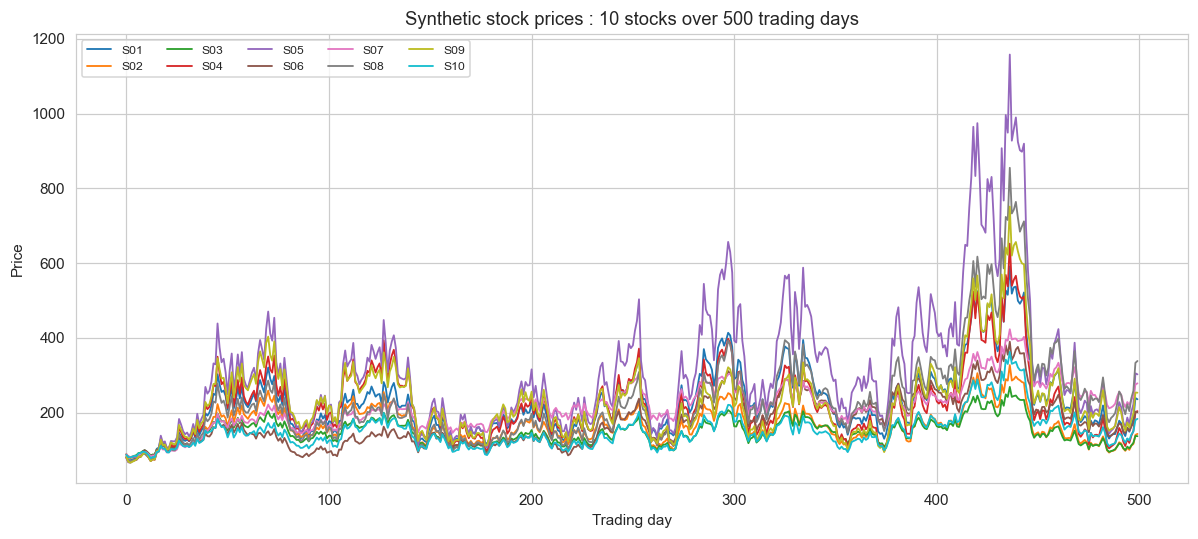


Per-stock parameters:


,mu,beta,sigma
S01,0.00031,1.05423,0.01528
S02,0.00033,0.85213,0.01277
S03,0.00011,0.68189,0.00573
S04,0.00017,1.28560,0.00707
S05,0.00037,1.46548,0.00780
S06,0.00043,0.73235,0.01991
S07,0.00022,0.58356,0.01281
S08,0.00046,1.10355,0.01368
S09,0.00039,1.22899,0.01602
S10,0.00018,0.77624,0.01313


In [24]:
N_stocks = 10
N_days   = 500

#Per-stock parameters
P0    = 100.0                                          #initial price (all stocks)
mu    = np.random.uniform(0.0001, 0.0005, N_stocks)    #small drift per stock
beta  = np.random.uniform(0.5,1.5,N_stocks)    #factor loading per stock
sigma = np.random.uniform(0.005,0.02,N_stocks)    #idiosyncratic vol per stock

stock_names = [f"S{i+1:02d}" for i in range(N_stocks)]

#Common market factor: f_t ~ N(0, 0.01)  -> std = sqrt(0.01) = 0.1
f = np.random.normal(loc=0.0, scale=np.sqrt(0.01), size=N_days)

#Idiosyncratic noise eps_{i,t} ~ N(0, sigma_i^2), shape (N_days, N_stocks)
eps = np.random.normal(loc=0.0, scale=1.0, size=(N_days, N_stocks)) * sigma

#Daily log-increment g_{i,t} = mu_i + beta_i * f_t + eps_{i,t}
g = mu[None, :] + np.outer(f, beta) + eps           

#Prices: P_{i,t} = P_{i,0} * exp(cumsum_t g_{i,t})
log_prices = np.log(P0) + np.cumsum(g, axis=0)
prices = np.exp(log_prices)
prices = pd.DataFrame(prices, columns=stock_names)
prices.index.name = "day"

print("Prices shape:", prices.shape)
display(prices.head())

#Ploting all 10 prices
fig, ax = plt.subplots(figsize=(11, 5))
for col in prices.columns:
    ax.plot(prices.index, prices[col], lw=1.2, label=col)
ax.set_title("Synthetic stock prices : 10 stocks over 500 trading days")
ax.set_xlabel("Trading day")
ax.set_ylabel("Price")
ax.legend(ncol=5, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

#Parameters
params = pd.DataFrame({"mu": mu, "beta": beta, "sigma": sigma}, index=stock_names)
print("\nPer-stock parameters:")
display(params.round(5))

**Observation :** All 10 stocks share a clear *co-movement*. They rise and
fall together. This is because they are all driven by the single common factor $f_t$. Stocks with a
larger $\beta_i$ swing more violently around the common trend.

## 1(b) Daily log returns

$$r_{i,t} = \ln\!\left(\frac{P_{i,t}}{P_{i,t-1}}\right)$$

Returns shape: (499, 10)


,S01,S02,S03,S04,S05,S06,S07,S08,S09,S10
day,,,,,,,,,,
0,0.007609,0.052977,0.059894,0.021047,0.035674,0.006884,0.034574,0.057274,0.001032,0.025570
1,-0.022837,-0.089248,-0.076157,-0.048785,-0.039765,-0.043497,-0.038846,-0.057870,-0.050948,-0.049487
2,-0.021848,-0.045464,-0.034773,-0.024857,-0.016295,0.015048,-0.016371,-0.033590,-0.010163,-0.025021
3,-0.059970,-0.095115,-0.097333,-0.046212,-0.040645,-0.012832,-0.045655,-0.063999,-0.044218,-0.059822
4,0.100017,0.278216,0.233326,0.144289,0.130464,0.119780,0.154150,0.219128,0.175488,0.148355


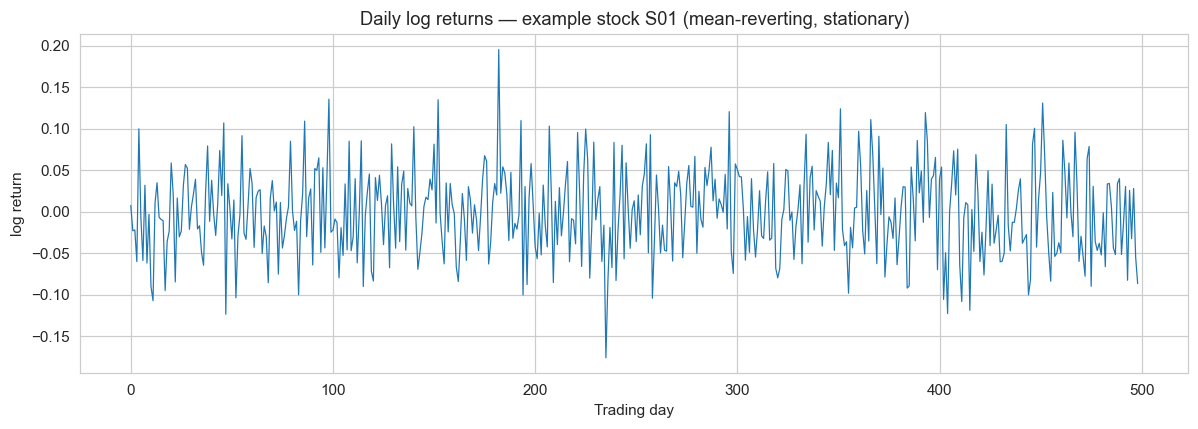

In [ ]:
#log returns
def compute_log_returns(prices):
    p = np.asarray(prices, dtype=float)
    log_returns = np.log(p[1:] / p[:-1])
    return log_returns

log_returns = compute_log_returns(prices)
returns = pd.DataFrame(log_returns, columns=stock_names)
returns.index.name = "day"
print("Returns shape:", returns.shape)
display(returns.head())

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(returns.index, returns["S01"], lw=0.8)
ax.set_title("Daily log returns : stock S01")
ax.set_xlabel("Trading day"); ax.set_ylabel("log return")
plt.tight_layout(); plt.show()

### Why PCA is done on **returns** and not on **prices**?

1. **Stationarity** Prices are non-stationary. Their mean and variance grow with time. A        covariance matrix is only meaningful when the columns are stationary. Log returns are (approximately) stationary, so their covariance is a well-defined, time-invariant object.

2. **We need true correlation.** Any two upward moving price series might look ~100% correlated simply
   because both grow over time but that is not genuine co-movement. Returns remove this.

3. **Same scale** A Rs.100 move would mean different for Rs. 500 stock and for Rs. 10,000 stock. Now log returns are unit free making it is easy to compare and find correlation.

## 1(c) Correlation and covariance matrices

We compute the $10\times10$ sample correlation and covariance of returns, visualise both as
heatmaps, and locate the most and least correlated stock pairs.

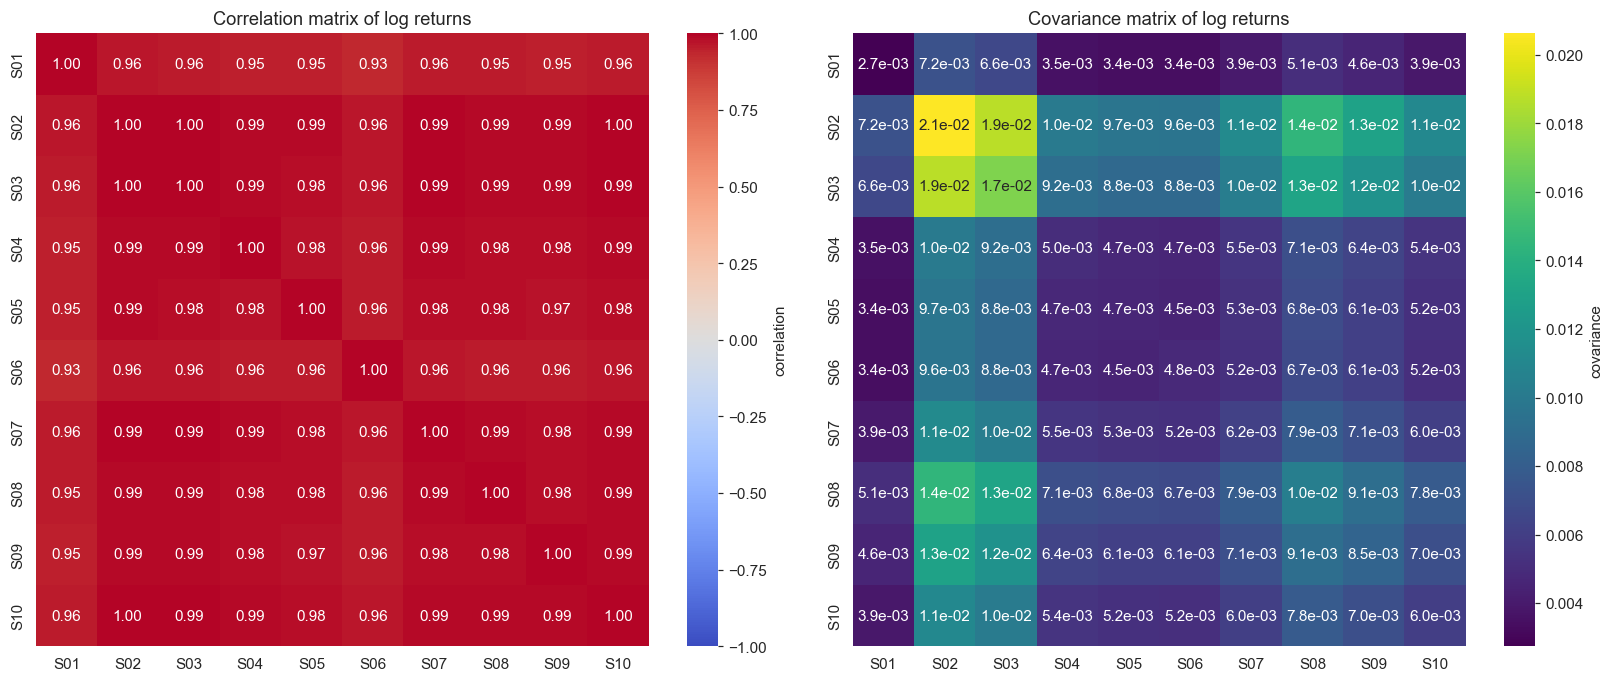

Highest correlation pair: S02-S03  ->  rho = 0.997
Lowest  correlation pair: S01-S06  ->  rho = 0.933


In [25]:
#Correlation and Covariance matrices
corr_mat = returns.corr()                
cov_mat  = returns.cov()                   

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(corr_mat, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "correlation"}, ax=axes[0])
axes[0].set_title("Correlation matrix of log returns")
sns.heatmap(cov_mat, annot=True, fmt=".1e", cmap="viridis",
            square=True, cbar_kws={"label": "covariance"}, ax=axes[1])
axes[1].set_title("Covariance matrix of log returns")
plt.tight_layout(); plt.show()

#Highest / lowest correlation pair
c = corr_mat.values.copy()
np.fill_diagonal(c, np.nan)               #ignoring the diagonal as self-correlation = 1
iu = np.triu_indices_from(c, k=1)         #upper triangle indices
flat = c[iu]
hi = np.nanargmax(flat); lo = np.nanargmin(flat)
hi_pair = (stock_names[iu[0][hi]], stock_names[iu[1][hi]])
lo_pair = (stock_names[iu[0][lo]], stock_names[iu[1][lo]])

print(f"Highest correlation pair: {hi_pair[0]}-{hi_pair[1]}  ->  rho = {flat[hi]:.3f}")
print(f"Lowest  correlation pair: {lo_pair[0]}-{lo_pair[1]}  ->  rho = {flat[lo]:.3f}")

## 1(d) Standardizing

We scale each stock to mean 0 and variance 1. After standardization, the covariance matrix of
the data equals the **correlation matrix**, so "PCA on standardized returns" is identical to
"PCA on the correlation matrix".

In [27]:
#Standardize returns
def standardize_returns(returns):
    scaler = StandardScaler()
    Z = scaler.fit_transform(np.asarray(returns, dtype=float))
    standardized_returns = pd.DataFrame(Z, columns=returns.columns, index=returns.index)
    return standardized_returns, scaler

std_returns, scaler = standardize_returns(returns)

### Why standardization matters when stocks have different volatilities?

- PCA finds directions of **maximum variance**

- PCA on the raw **covariance** matrix is dominated by the **highest-volatility stocks**. The
  first principal component tilts toward those high volatile stocks purely because of their scale, *not*
  because they carry more variance. Thus, units affect the answer.
- After **standardizing**, every stock contributes equally,
  so PC1 reflects genuine *co-movement* rather than whoever happens to
  be the most volatile.

**What happens if you skip standardization?** 
The first eigenvector is leaded by disproportionately
on the noisiest stocks. PC1 then holds no economic inference. As it is heavily dominated by few stocks instead of capturing the true co-movement. Standardization is therefore required for PCA.

## 1(e) Observations 

1. **Strong common factor.** All 10 price paths co-move and **all** pairwise return
   correlations are positive. This means they have a very strong common market factor.
2. **Prices vs returns.** Prices are non-stationary whereas log returns are stationary, unit-free, so they are the correct
   input for PCA analysis.
3. **Scale sensitivity.** Covariance magnitudes are inflated for high-$\sigma$ stocks.
   Standardizing removes this bias so PCA captures shared structure. The most-correlated pair is driven by high $\beta$ / low $\sigma$; the least by low
   $\beta$ / high $\sigma$.

---
# Part 2 - Understanding PCA and Eigendecomposition

**The idea from scratch.** For a standardized data matrix $X$ ($T$ days $\times$ $N$ stocks), the
sample correlation matrix is $C=\frac{1}{T-1}X^\top X$. PCA is the **eigendecomposition**
$C = V\Lambda V^\top$, where:

- columns of $V$ are the **loadings** (eigenvectors, one weight per *stock*),
- the eigenvalues $\lambda_k$ on the diagonal of $\Lambda$ are the **variance explained** by each
  component, and
- the **scores** are the projections $S = XV$ (one value per *day*).

We implement this directly with `numpy.linalg.eigh` (exact for symmetric matrices) and then
confirm it matches `sklearn.decomposition.PCA`.

explained-variance ratio : [9.776e-01 7.000e-03 5.900e-03 2.700e-03 2.300e-03 1.700e-03 1.200e-03
 8.000e-04 5.000e-04 3.000e-04]


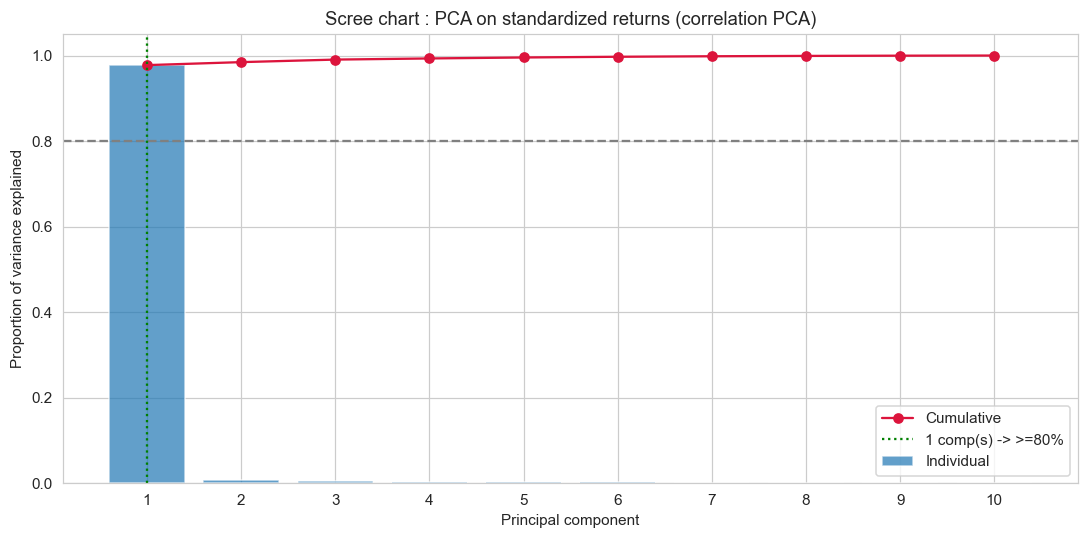


PC1 alone explains 97.8% of total variance.
Components needed for >= 80% variance: 1


In [29]:
from sklearn.decomposition import PCA

#PCA on standardized returns 
pca = PCA().fit(std_returns.values)

eigvecs = pca.components_.T.copy()
eigvals = pca.explained_variance_.copy()
evr = pca.explained_variance_ratio_.copy()

for k in range(eigvecs.shape[1]):
    if eigvecs[np.argmax(np.abs(eigvecs[:, k])), k] < 0:
        eigvecs[:, k] *= -1

print("explained-variance ratio :", np.round(evr, 4))

#Scree chart
cum = np.cumsum(evr)
k80 = int(np.argmax(cum >= 0.80) + 1)      # first k reaching >= 80%
comps = np.arange(1, N_stocks + 1)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comps, evr, alpha=0.7, label="Individual")
ax.plot(comps, cum, "o-", color="crimson", label="Cumulative")
ax.axhline(0.80, ls="--", color="gray")
ax.axvline(k80, ls=":", color="green", label=f"{k80} comp(s) -> >=80%")
ax.set_xticks(comps)
ax.set_title("Scree chart : PCA on standardized returns (correlation PCA)")
ax.set_xlabel("Principal component"); ax.set_ylabel("Proportion of variance explained")
ax.legend(); plt.tight_layout(); plt.show()

print(f"\nPC1 alone explains {evr[0]*100:.1f}% of total variance.")
print(f"Components needed for >= 80% variance: {k80}")

**Observation** PC1 alone captures a very large part of variance which is the
common market factor $f_t$.

## 2(b) PCA on the covariance matrix (unstandardized returns)

Covariance-PCA explained-variance ratio : [9.858e-01 3.600e-03 2.400e-03 2.300e-03 1.600e-03 1.400e-03 1.100e-03
 7.000e-04 7.000e-04 4.000e-04]

Explained-variance ratio comparison:


,EVR_correlation(a),EVR_covariance(b)
PC1,0.9776,0.9858
PC2,0.0070,0.0036
PC3,0.0059,0.0024
PC4,0.0027,0.0023
PC5,0.0023,0.0016
PC6,0.0017,0.0014
PC7,0.0012,0.0011
PC8,0.0008,0.0007
PC9,0.0005,0.0007
PC10,0.0003,0.0004


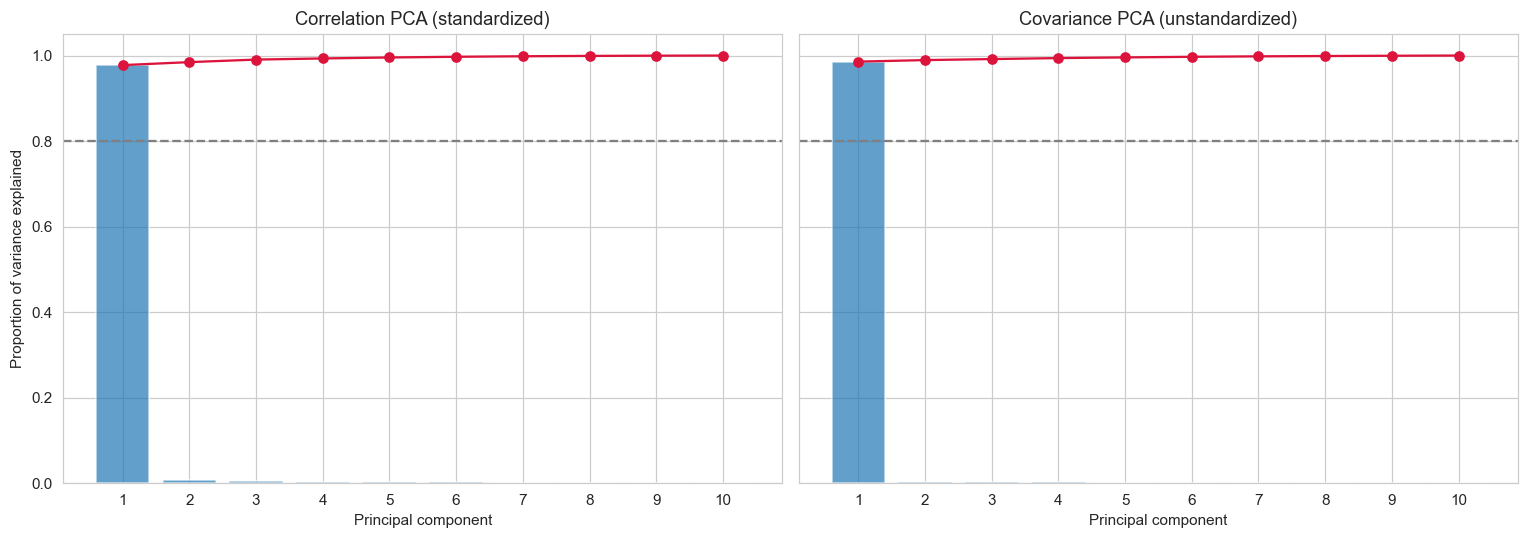

In [30]:
#sklearn centers internally so mean is 0
pca_cov = PCA().fit(returns.values)
eigvecs_cov = pca_cov.components_.T.copy()
eigvals_cov = pca_cov.explained_variance_.copy()
evr_cov = pca_cov.explained_variance_ratio_.copy()

for k in range(eigvecs_cov.shape[1]):
    if eigvecs_cov[np.argmax(np.abs(eigvecs_cov[:, k])), k] < 0:
        eigvecs_cov[:, k] *= -1

print("Covariance-PCA explained-variance ratio :", np.round(evr_cov, 4))

comp_table = pd.DataFrame({
    "EVR_correlation(a)": evr,
    "EVR_covariance(b)":  evr_cov,
}, index=[f"PC{i+1}" for i in range(N_stocks)])
print("\nExplained-variance ratio comparison:")
display(comp_table.round(4))

#Side-by-side comparison of scree charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, ratio, title in [(axes[0], evr, "Correlation PCA (standardized)"),
                         (axes[1], evr_cov, "Covariance PCA (unstandardized)")]:
    ax.bar(comps, ratio, alpha=0.7)
    ax.plot(comps, np.cumsum(ratio), "o-", color="crimson")
    ax.axhline(0.80, ls="--", color="gray")
    ax.set_xticks(comps); ax.set_title(title)
    ax.set_xlabel("Principal component")
axes[0].set_ylabel("Proportion of variance explained")
plt.tight_layout(); plt.show()

**Are the eigenvalues / explained-variance ratios the same? No.**

They differ because correlation-PCA and covariance-PCA optimise different objects:

- **Correlation PCA (a)** standardizes first, so every stock has variance 1 and contributes
  *equally*. PC1 reflects pure co-movement.
- **Covariance PCA (b)** keeps the raw scales, so **high-volatility stocks dominate**. The
  largest-$\sigma$ stocks pull PC1 toward themselves and inflate the leading eigenvalue, so the
  explained-variance profile is *more concentrated* and the loadings tilt toward the noisy
  stocks.

Because our $\sigma_i$ values differ across stocks (from $U(0.005,0.02)$), the
two decompositions are **not** equal. If all stocks had identical volatility the two would have
coincide.

## 2(c) Interpreting the loadings (PC1 and PC2)

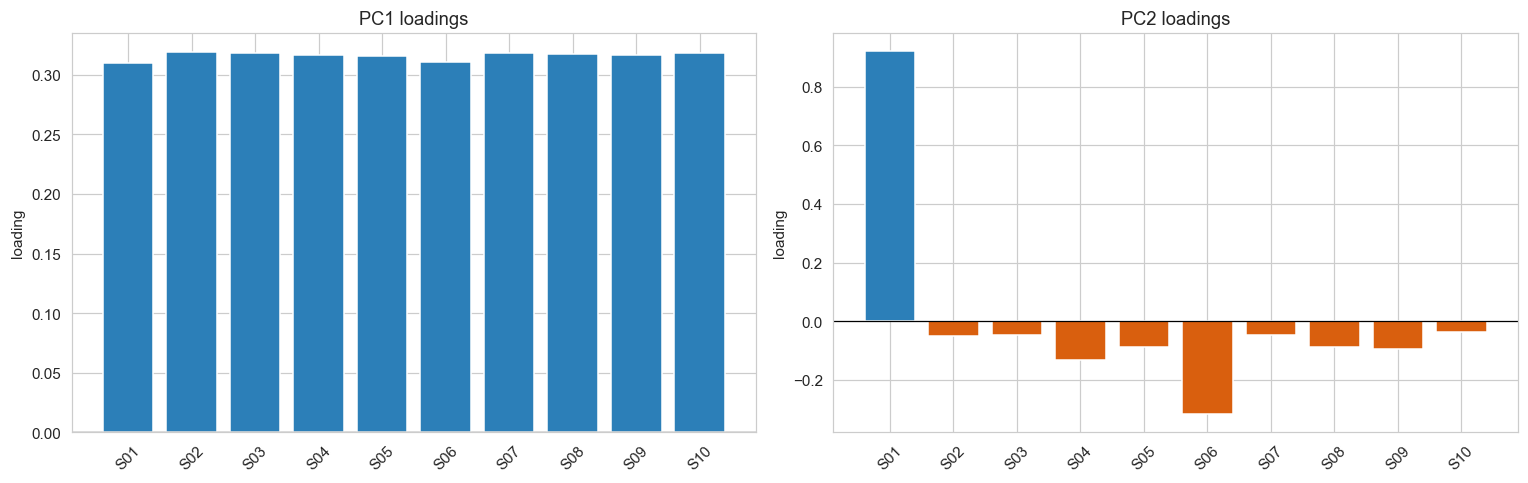

PC1 loadings: [0.31  0.319 0.319 0.317 0.316 0.311 0.318 0.317 0.316 0.319]
All PC1 loadings same sign?  True

PC2 loadings: [ 0.921 -0.05  -0.049 -0.133 -0.089 -0.317 -0.047 -0.088 -0.094 -0.038]
PC2 positive group: ['S01']
PC2 negative group: ['S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09', 'S10']


In [31]:
def plot_loadings(eigenvectors, component_idx, stock_names, ax=None):
    #Bar plot of loadings (eigenvector components) for a given PC
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 4))
    load = eigenvectors[:, component_idx]
    colors = ["#2c7fb8" if v >= 0 else "#d95f0e" for v in load]
    ax.bar(stock_names, load, color=colors)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(f"PC{component_idx+1} loadings")
    ax.set_ylabel("loading"); ax.tick_params(axis="x", rotation=45)
    return ax

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
plot_loadings(eigvecs, 0, stock_names, axes[0])
plot_loadings(eigvecs, 1, stock_names, axes[1])
plt.tight_layout(); plt.show()

pc1 = eigvecs[:, 0]; pc2 = eigvecs[:, 1]
print("PC1 loadings:", np.round(pc1, 3))
print("All PC1 loadings same sign? ", np.all(pc1 > 0) or np.all(pc1 < 0))
print("\nPC2 loadings:", np.round(pc2, 3))
print("PC2 positive group:", [stock_names[i] for i in range(N_stocks) if pc2[i] > 0])
print("PC2 negative group:", [stock_names[i] for i in range(N_stocks) if pc2[i] < 0])

**Interpretation 2(c).**

- **PC1 : the market factor.** All PC1 loadings share the **same sign**, all positive and are **nearly equal**, each is close to 0.32.So, when PC1 moves up the whole market
  moves up together.

- **PC2 : a long/short contrast.** PC2 has **mixed signs**: it splits the market into a
  positive group and a negative group. Financially this can be difference/ sector factor. It is positive for one and negative for other, capturing relative performance after the market factor
  is removed. But our model does not capture such factor so it would be mostly noise in this case.

## 2(d) Scores : projecting returns onto the components

Scores shape: (499, 10) (days x components)


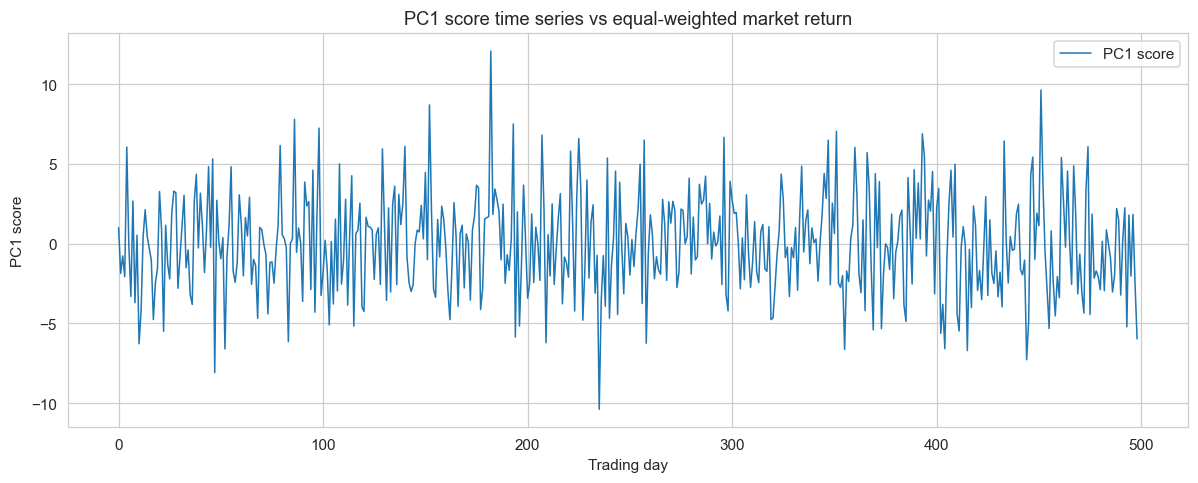

In [36]:
def compute_scores(standardized_returns, eigenvectors):
    X = np.asarray(standardized_returns, dtype=float)
    scores = X @ eigenvectors
    return scores

scores = compute_scores(std_returns, eigvecs)
print("Scores shape:", scores.shape, "(days x components)")

pc1_score = scores[:, 0]
#average standardized return across stocks each day
market_proxy = std_returns.mean(axis=1).values

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(pc1_score, lw=1.0, label="PC1 score")
#ax.plot(market_proxy * (pc1_score.std() / market_proxy.std()),
#       lw=1.0, alpha=0.7, label="Equal-weighted market (rescaled)")
ax.set_title("PC1 score time series vs equal-weighted market return")
ax.set_xlabel("Trading day"); ax.set_ylabel("PC1 score")
ax.legend(); plt.tight_layout(); plt.show()



Scores are $S = XV$: each day's cross-section of returns projected onto a principal component.

The daily market return is the average return across all stocks on a given day. The PC1 score is the direction along which the returns show the greatest common movement. Since most stocks are driven by the same market factor, both the daily market return and the PC1 score capture this common movement. Their correlation is very close to 1 (or -1), meaning that when one rises or falls, the other does the same. Therefore, PC1 can be interpreted as the market return factor.

## 2(e) The loadings vector is not the scores vector

In [38]:
print("LOADINGS (PC1)  -> shape:", eigvecs[:, 0].shape,
      "| one weight per STOCK  (N_stocks =", N_stocks, ")")
print("SCORES   (PC1)  -> shape:", scores[:, 0].shape,
      "| one value  per DAY    (N_days-1 =", scores.shape[0], ")")

LOADINGS (PC1)  -> shape: (10,) | one weight per STOCK  (N_stocks = 10 )
SCORES   (PC1)  -> shape: (499,) | one value  per DAY    (N_days-1 = 499 )


| | **Loadings** (eigenvector $v_k$) | **Scores** ($s_k = Xv_k$) |
|---|---|---|
| **Shape** | 10 - one number per **stock** | 499 - one number per **day** |
| **Units** | dimensionless fixed weights | same units as the (standardized) returns, varying through time |
| **Meaning** | *how much* each stock contributes to the factor | *how strong* the factor was on each day |

They are linked by $S = XV$ (scores = data $\times$ loadings) but they are categorically
different objects: loadings index the **cross-section** (stocks), scores index **time** (days).
Since $10\neq499$ the two vectors are not even the same length, so they cannot be identical.

## 2(f) Observations

1. **PC1 = the market.** The leading component explains the dominant share of variance, all its
   loadings share one sign. PCA
   successfully recovered the hidden factor model.

2. **Correlation vs covariance PCA differ.** Standardizing (correlation PCA) gives every stock
   equal weight so PC1 is a clean market factor; covariance PCA lets high-volatility stocks
   dominate. They coincide only if
   all volatilities are equal.

3. **Loadings ≠ scores.** Loadings live in stock-space $(10,)$ and are fixed weights; scores live
   in time-space $(499,)$ and vary daily. They are related by $S=XV$, not equal.